<a href="https://colab.research.google.com/github/aarav06-bit/CS131_release/blob/master/spring_2026/crystal_density_classification/crystal_density_calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk

from scipy.ndimage import gaussian_filter
from scipy.ndimage import rotate
import os
import pandas as pd
from skimage.feature import peak_local_max

In [4]:
MATERIALS = [

    # FCC
    {
        'element': 'Au',
        'structure': 'fcc',
        'a': 4.08
    },

    {
        'element': 'Al',
        'structure': 'fcc',
        'a': 4.05
    },

    {
        'element': 'Cu',
        'structure': 'fcc',
        'a': 3.61
    },

    # BCC
    {
        'element': 'Fe',
        'structure': 'bcc',
        'a': 2.87
    },

    {
        'element': 'Cr',
        'structure': 'bcc',
        'a': 2.91
    },

    # HCP
    {
        'element': 'Ti',
        'structure': 'hcp',
        'a': 2.95,
        'c': 4.68
    },

    {
        'element': 'Mg',
        'structure': 'hcp',
        'a': 3.21,
        'c': 5.21
    }
]

In [5]:
AVOGADRO = 6.022e23

ATOMS_PER_CELL = {
    'fcc': 4,
    'bcc': 2,
    'hcp': 6
}

def compute_density(structure, mass, lattice_constant):

    n = ATOMS_PER_CELL[structure]

    # convert angstroms to cm
    a_cm = lattice_constant * 1e-8

    volume = a_cm**3

    density = (n * mass) / (AVOGADRO * volume)

    return density

In [6]:
def generate_crystal_image(
    material,
    repetitions=(8,8,4),
    grid_size=128,
    sigma=2,
    noise_level=0.01,
    rotation_angle=0
):

    structure = material['structure']

    # Create crystal
    if structure == 'hcp':

        atoms = bulk(
            material['element'],
            structure,
            a=material['a'],
            c=material['c']
        )

    else:

        atoms = bulk(
            material['element'],
            structure,
            a=material['a']
        )

    atoms = atoms.repeat(repetitions)

    # Atomic positions
    positions = atoms.get_positions()

    x = positions[:,0]
    y = positions[:,1]

    # Normalize coordinates
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # Create image
    image = np.zeros((grid_size, grid_size))

    x_pix = (x_norm * (grid_size - 1)).astype(int)
    y_pix = (y_norm * (grid_size - 1)).astype(int)

    # Place atoms
    for xp, yp in zip(x_pix, y_pix):
        image[yp, xp] += 1

    # Blur
    image = gaussian_filter(image, sigma=sigma)

    # Rotate
    image = rotate(
        image,
        angle=rotation_angle,
        reshape=False
    )

    # Add noise
    noise = np.random.normal(
        0,
        noise_level,
        image.shape
    )

    image += noise

    # Normalize
    image -= image.min()
    image /= image.max()

    return image

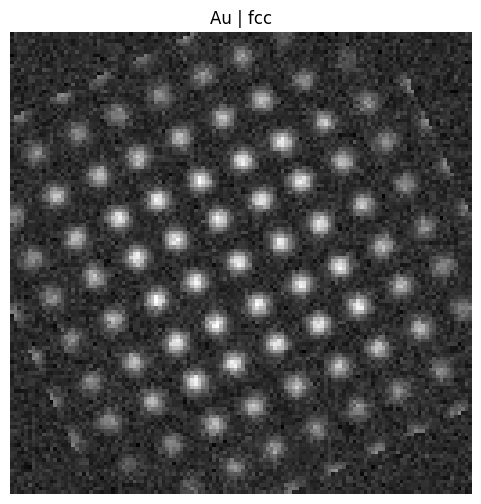

In [8]:
# Test material
material = MATERIALS[0]

# Generate image
image = generate_crystal_image(
    material,
    rotation_angle=25
)

# Display image
plt.figure(figsize=(6,6))

plt.imshow(image, cmap='gray')

plt.title(
    f"{material['element']} | "
    f"{material['structure']}"
)

plt.axis('off')

plt.show()

In [10]:
# Create folders
os.makedirs("dataset/images", exist_ok=True)

# Metadata storage
metadata_list = []

sample_id = 0

# Generate dataset
for material in MATERIALS:

    for rotation in range(0, 180, 15):

        for noise_level in [0.005, 0.01, 0.02]:

            # Generate image
            image = generate_crystal_image(
                material,
                rotation_angle=rotation,
                noise_level=noise_level
            )

            filename = f"sample_{sample_id:04d}.npy"

            # Save image
            np.save(
                f"dataset/images/{filename}",
                image
            )

            # Store metadata
            metadata_list.append({

                'filename': filename,

                'element': material['element'],

                'structure': material['structure'],

                'rotation': rotation,

                'noise_level': noise_level
            })

            sample_id += 1

# Save metadata CSV
metadata_df = pd.DataFrame(metadata_list)

metadata_df.to_csv(
    "dataset/metadata.csv",
    index=False
)

print("Dataset generation complete.")
print(f"Total samples: {sample_id}")

Dataset generation complete.
Total samples: 252


In [11]:
feature_data = []

for idx in range(len(metadata_df)):

    # Load image
    filename = metadata_df.iloc[idx]['filename']

    structure = metadata_df.iloc[idx]['structure']

    image = np.load(
        f"dataset/images/{filename}"
    )

    # Compute FFT
    fft = np.fft.fftshift(
        np.fft.fft2(image)
    )

    magnitude = np.log(np.abs(fft) + 1)

    # Detect FFT peaks
    coordinates = peak_local_max(
        magnitude,
        min_distance=3,
        threshold_abs=1.5,
        num_peaks=20
    )

    # FFT center
    center_y = magnitude.shape[0] // 2
    center_x = magnitude.shape[1] // 2

    distances = []

    for coord in coordinates:

        y, x = coord

        # Skip center peak
        if abs(x - center_x) < 5 and abs(y - center_y) < 5:
            continue

        distance = np.sqrt(
            (x - center_x)**2 +
            (y - center_y)**2
        )

        distances.append(distance)

    distances = np.array(distances)

    # Skip images with no peaks
    if len(distances) == 0:
        continue

    # Fourier features
    mean_distance = np.mean(distances)

    std_distance = np.std(distances)

    min_distance = np.min(distances)

    max_distance = np.max(distances)

    num_peaks = len(distances)

    # Store features
    feature_data.append({

        'mean_distance': mean_distance,

        'std_distance': std_distance,

        'min_distance': min_distance,

        'max_distance': max_distance,

        'num_peaks': num_peaks,

        'structure': structure
    })

# Create dataframe
features_df = pd.DataFrame(feature_data)

# Display first rows
features_df.head()

,mean_distance,std_distance,min_distance,max_distance,num_peaks,structure
0,17.531226,4.922911,10.000000,22.360680,19,fcc
1,17.531226,4.922911,10.000000,22.360680,19,fcc
2,17.531226,4.922911,10.000000,22.360680,19,fcc
3,17.776936,4.966364,10.440307,22.671568,19,fcc
4,17.766391,4.956398,10.440307,22.671568,19,fcc


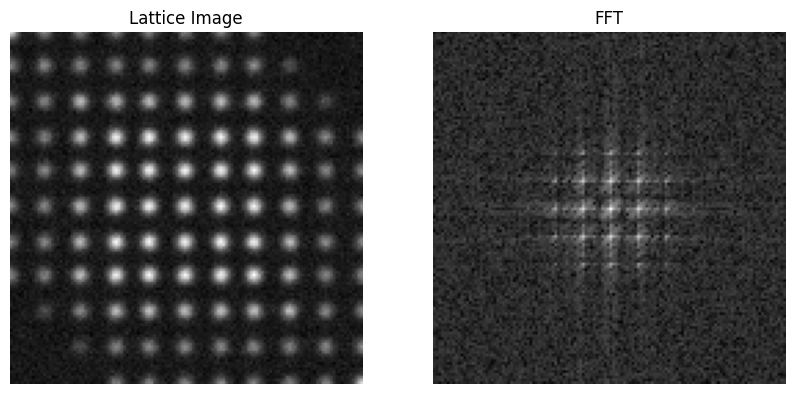

In [12]:
sample = np.load("dataset/images/sample_0000.npy")

fft = np.fft.fftshift(
    np.fft.fft2(sample)
)

magnitude = np.log(np.abs(fft) + 1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(sample, cmap='gray')

plt.title("Lattice Image")

plt.axis('off')

plt.subplot(1,2,2)

plt.imshow(magnitude, cmap='gray')

plt.title("FFT")

plt.axis('off')

plt.show()

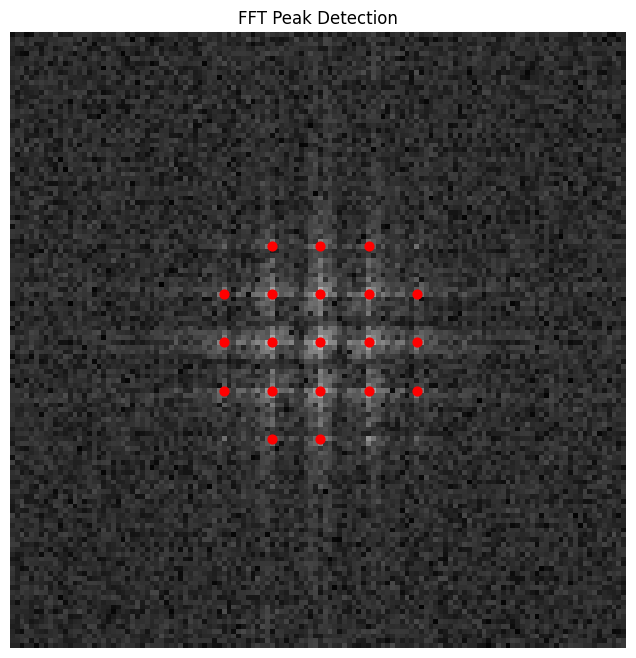

In [14]:
sample = np.load("dataset/images/sample_0000.npy")

# Compute FFT
fft = np.fft.fftshift(
    np.fft.fft2(sample)
)

magnitude = np.log(np.abs(fft) + 1)

# Detect peaks
coordinates = peak_local_max(
    magnitude,
    min_distance=3,
    threshold_abs=1.5,
    num_peaks=20
)

# Display FFT
plt.figure(figsize=(8,8))

plt.imshow(magnitude, cmap='gray')

# Overlay detected peaks
plt.scatter(
    coordinates[:,1],
    coordinates[:,0],
    c='red',
    s=40
)

plt.title("FFT Peak Detection")

plt.axis('off')

plt.show()

Detected coordinates:
[[64 64]
 [64 54]
 [64 74]
 [54 64]
 [74 64]
 [54 74]
 [74 54]
 [54 54]
 [74 74]
 [64 44]
 [64 84]
 [44 64]
 [84 64]
 [44 74]
 [84 54]
 [54 84]
 [74 44]
 [54 44]
 [74 84]
 [44 54]]

Peak distances:
[10.         10.         10.         10.         14.14213562 14.14213562
 14.14213562 14.14213562 20.         20.         20.         20.
 22.36067977 22.36067977 22.36067977 22.36067977 22.36067977 22.36067977
 22.36067977]


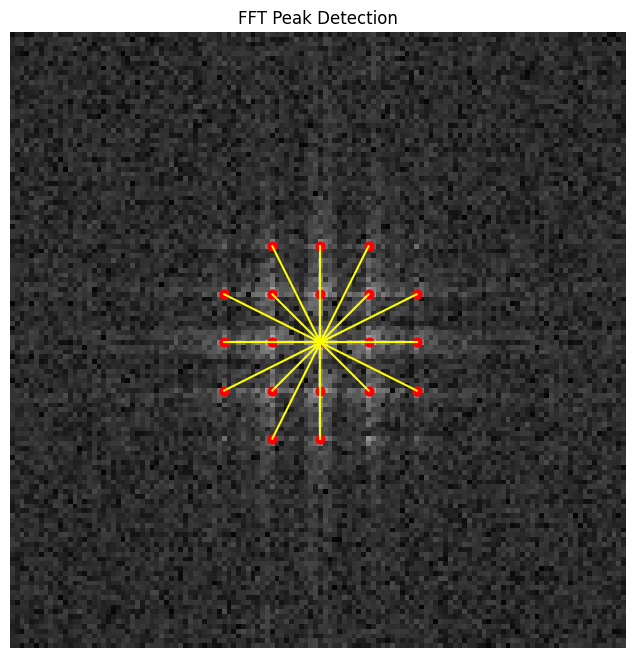

In [15]:
from skimage.feature import peak_local_max

# Load sample image
sample = np.load("dataset/images/sample_0000.npy")

# Compute FFT
fft = np.fft.fftshift(
    np.fft.fft2(sample)
)

# FFT magnitude
magnitude = np.log(np.abs(fft) + 1)

# Detect FFT peaks
coordinates = peak_local_max(
    magnitude,
    min_distance=3,
    threshold_abs=1.5,
    num_peaks=20
)

print("Detected coordinates:")
print(coordinates)

# FFT center
center_y = magnitude.shape[0] // 2
center_x = magnitude.shape[1] // 2

# Compute distances from center
distances = []

for coord in coordinates:

    y, x = coord

    # Skip center peak
    if abs(x - center_x) < 5 and abs(y - center_y) < 5:
        continue

    distance = np.sqrt(
        (x - center_x)**2 +
        (y - center_y)**2
    )

    distances.append(distance)

distances = np.array(distances)

print("\nPeak distances:")
print(distances)

# Visualize FFT peaks
plt.figure(figsize=(8,8))

plt.imshow(magnitude, cmap='gray')

plt.scatter(
    coordinates[:,1],
    coordinates[:,0],
    c='red',
    s=40
)

# Draw lines from center
for coord in coordinates:

    y, x = coord

    plt.plot(
        [center_x, x],
        [center_y, y],
        'yellow'
    )

plt.title("FFT Peak Detection")

plt.axis('off')

plt.show()

In [16]:
# Fourier feature extraction

mean_distance = np.mean(distances)

std_distance = np.std(distances)

min_distance = np.min(distances)

max_distance = np.max(distances)

num_peaks = len(distances)

print("Mean distance:", mean_distance)

print("Std distance:", std_distance)

print("Min distance:", min_distance)

print("Max distance:", max_distance)

print("Number of peaks:", num_peaks)

Mean distance: 17.53122636420574
Std distance: 4.922910677170428
Min distance: 10.0
Max distance: 22.360679774997898
Number of peaks: 19


In [18]:
feature_data = []

for idx in range(len(metadata_df)):

    # Load image
    filename = metadata_df.iloc[idx]['filename']

    structure = metadata_df.iloc[idx]['structure']

    image = np.load(
        f"dataset/images/{filename}"
    )

    # Compute FFT
    fft = np.fft.fftshift(
        np.fft.fft2(image)
    )

    magnitude = np.log(np.abs(fft) + 1)

    # Detect FFT peaks
    coordinates = peak_local_max(
        magnitude,
        min_distance=3,
        threshold_abs=1.5,
        num_peaks=20
    )

    # FFT center
    center_y = magnitude.shape[0] // 2
    center_x = magnitude.shape[1] // 2

    distances = []

    for coord in coordinates:

        y, x = coord

        # Skip center peak
        if abs(x - center_x) < 5 and abs(y - center_y) < 5:
            continue

        distance = np.sqrt(
            (x - center_x)**2 +
            (y - center_y)**2
        )

        distances.append(distance)

    distances = np.array(distances)

    # Skip images with no peaks
    if len(distances) == 0:
        continue

    # Fourier feature extraction
    mean_distance = np.mean(distances)

    std_distance = np.std(distances)

    min_distance = np.min(distances)

    max_distance = np.max(distances)

    num_peaks = len(distances)

    # Store features
    feature_data.append({

        'mean_distance': mean_distance,

        'std_distance': std_distance,

        'min_distance': min_distance,

        'max_distance': max_distance,

        'num_peaks': num_peaks,

        'structure': structure
    })

# Create dataframe
features_df = pd.DataFrame(feature_data)

print(features_df.head())

   mean_distance  std_distance  min_distance  max_distance  num_peaks  \
0      17.531226      4.922911     10.000000     22.360680         19   
1      17.531226      4.922911     10.000000     22.360680         19   
2      17.531226      4.922911     10.000000     22.360680         19   
3      17.776936      4.966364     10.440307     22.671568         19   
4      17.766391      4.956398     10.440307     22.671568         19   

  structure  
0       fcc  
1       fcc  
2       fcc  
3       fcc  
4       fcc  


In [19]:
features_df['structure'].value_counts()

,count
structure,
fcc,108
bcc,72
hcp,72


In [20]:
from sklearn.model_selection import train_test_split

# Input features
X = features_df[[
    'mean_distance',
    'std_distance',
    'min_distance',
    'max_distance',
    'num_peaks'
]]

# Labels
y = features_df['structure']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

Training samples: 201
Testing samples: 51


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create classifier
classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train classifier
classifier.fit(X_train, y_train)

# Predict structures
predictions = classifier.predict(X_test)

# Display results
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

         bcc       1.00      1.00      1.00        18
         fcc       1.00      1.00      1.00        21
         hcp       1.00      1.00      1.00        12

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51



In [22]:
STRUCTURE_INFO = {

    'fcc': 4,
    'bcc': 2,
    'hcp': 6
}

In [23]:
MATERIAL_PROPERTIES = {

    'Au': {
        'structure': 'fcc',
        'a': 4.08,
        'atomic_mass': 196.97
    },

    'Al': {
        'structure': 'fcc',
        'a': 4.05,
        'atomic_mass': 26.98
    },

    'Cu': {
        'structure': 'fcc',
        'a': 3.61,
        'atomic_mass': 63.55
    },

    'Fe': {
        'structure': 'bcc',
        'a': 2.87,
        'atomic_mass': 55.85
    },

    'Cr': {
        'structure': 'bcc',
        'a': 2.91,
        'atomic_mass': 52.00
    },

    'Ti': {
        'structure': 'hcp',
        'a': 2.95,
        'c': 4.68,
        'atomic_mass': 47.87
    },

    'Mg': {
        'structure': 'hcp',
        'a': 3.21,
        'c': 5.21,
        'atomic_mass': 24.31
    }
}

In [24]:
NA = 6.022e23

def calculate_density(material_name):

    material = MATERIAL_PROPERTIES[material_name]

    structure = material['structure']

    atomic_mass = material['atomic_mass']

    n = STRUCTURE_INFO[structure]

    # FCC and BCC
    if structure in ['fcc', 'bcc']:

        a = material['a'] * 1e-8

        volume = a**3

    # HCP
    elif structure == 'hcp':

        a = material['a'] * 1e-8

        c = material['c'] * 1e-8

        volume = (3 * np.sqrt(3) / 2) * (a**2) * c

    density = (n * atomic_mass) / (volume * NA)

    return density

In [25]:
print("Gold density:", calculate_density('Au'))

print("Iron density:", calculate_density('Fe'))

print("Titanium density:", calculate_density('Ti'))

Gold density: 19.263661391121232
Iron density: 7.84633292781121
Titanium density: 4.507462842109972
